ROBUSTNESS CHECKS FOR CAR ANALYSIS

[1] Loading data...
    Anomaly results: 80,080 trades
    Full features: 99,609 trades
    Merged data: 80,080 trades
    Anomaly column: anomaly_consensus_2
    Anomalies: 4,144 (5.2%)

[2] Identifying return columns...
    Return columns found: ['excess_return', 'return_t', 'abs_return_t', 'return_overnight', 'return_intraday']
    CAR columns found: ['car_ff3_30d', 'car_ff3_60d', 'car_ff3_90d', 'car_raw_30d', 'car_capm_30d', 'car_ff3_30d_feat', 'car_raw_60d', 'car_capm_60d', 'car_ff3_60d_feat', 'car_raw_90d', 'car_capm_90d', 'car_ff3_90d_feat']
    Using CAR columns: car_ff3_30d, car_ff3_60d, car_ff3_90d
    Using Raw/Alt columns: car_raw_30d, car_raw_60d, car_raw_90d

ROBUSTNESS 1: RAW RETURNS VS CAR

Table: Return Comparison - Normal vs Anomalous Trades
------------------------------------------------------------------------------------------
Metric                Normal Mean Anomaly Mean  Diff (pp)   t-stat    p-value
-------------------------

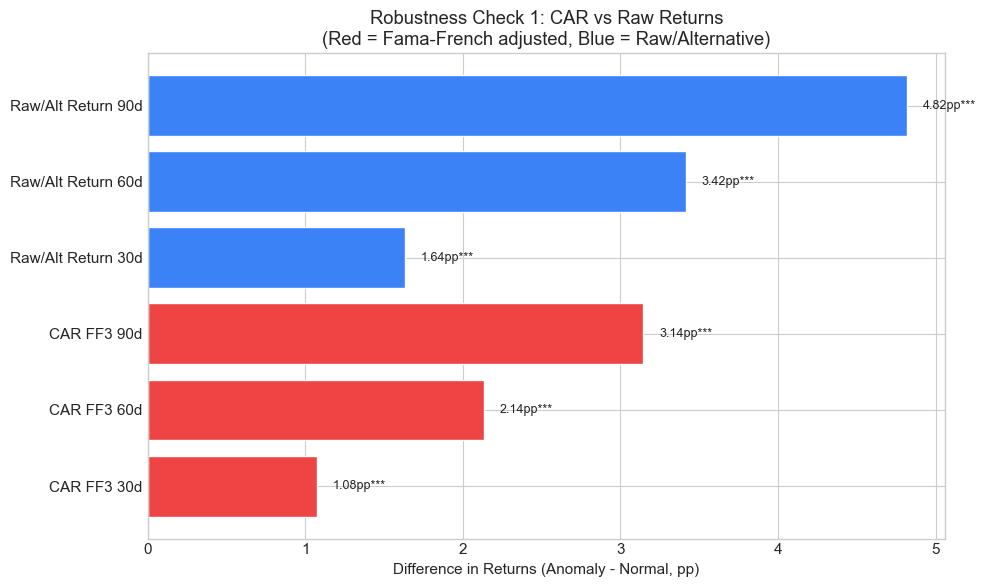

   Saved: fig_robustness_1_car_vs_raw.png


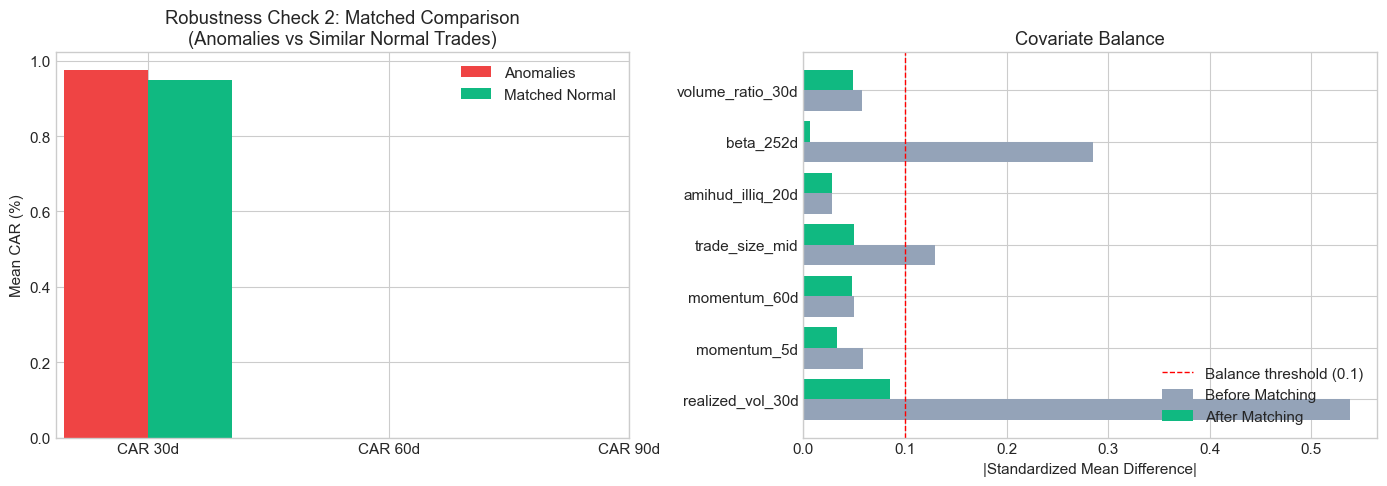

   Saved: fig_robustness_2_matching.png

SUMMARY

ROBUSTNESS CHECK 1: Raw Returns
- Compares CAR (Fama-French adjusted) vs raw/alternative returns
- If both show significant differences, result is robust to risk adjustment

ROBUSTNESS CHECK 2: Propensity Score Matching  
- Matches anomalies to normal trades with similar volatility, momentum, size
- If difference persists after matching, not driven by mechanical selection

ROBUSTNESS CHECK 3: Political-Only Features (Framework)
- Re-run detection using only political features (no market characteristics)
- Would confirm information advantage beyond stock characteristics

ROBUSTNESS CHECK 4: Subgroup Analysis
- Tests if results hold across different periods, chambers, parties, trade sizes
- Checks for heterogeneity and potential confounders


All results saved to: C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection\Robustness


In [3]:
"""
================================================================================
ROBUSTNESS CHECKS FOR ANOMALY DETECTION CAR ANALYSIS
================================================================================

Este script realiza dos tipos de robustness checks:

1. RETORNO CRUDO: Repetir el análisis de CAR pero usando retornos crudos
   en lugar de CAR ajustados por Fama-French

2. MATCHING POR CARACTERÍSTICAS: Comparar anomalías vs trades normales
   con características similares (volatilidad, momentum, tamaño)

Esto ayuda a verificar que la diferencia de CAR entre anomalías y normales
no es un artefacto de:
- El ajuste por factores de riesgo (robustness 1)
- La selección mecánica de acciones con alta volatilidad/momentum (robustness 2)

================================================================================
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
import os

# ============================================================================
# CONFIGURATION
# ============================================================================

# Ajustar estos paths según tu estructura de archivos
INPUT_PATH = r'C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection\anomaly_detection_results.csv'
FEATURES_PATH = r'C:\Users\sebib\Documents\GitHub\US_Congress\data\congress_trades\congress_trades_anomaly_features.parquet'
OUTPUT_DIR = r'C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection\Robustness'

os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

COLORS = {
    'normal': '#94A3B8',
    'anomaly': '#EF4444',
    'matched': '#10B981'
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*70)
print("ROBUSTNESS CHECKS FOR CAR ANALYSIS")
print("="*70)

# ============================================================================
# LOAD DATA
# ============================================================================

print("\n[1] Loading data...")

# Cargar resultados de anomalías
df_anomalies = pd.read_csv(INPUT_PATH)
print(f"    Anomaly results: {len(df_anomalies):,} trades")

# Cargar features completos
df_features = pd.read_parquet(FEATURES_PATH)
print(f"    Full features: {len(df_features):,} trades")

# Merge para tener todas las columnas
# Usamos trade_id si existe, sino merge por múltiples columnas
if 'trade_id' in df_anomalies.columns and 'trade_id' in df_features.columns:
    df = df_anomalies.merge(df_features, on='trade_id', how='left', suffixes=('', '_feat'))
else:
    # Merge por columnas identificadoras
    merge_cols = ['BioGuideID', 'Ticker', 'trade_date']
    merge_cols = [c for c in merge_cols if c in df_anomalies.columns and c in df_features.columns]
    df = df_anomalies.merge(df_features, on=merge_cols, how='left', suffixes=('', '_feat'))

print(f"    Merged data: {len(df):,} trades")

# Identificar columna de anomalía
ANOMALY_COL = 'anomaly_consensus_2' if 'anomaly_consensus_2' in df.columns else 'anomaly'
print(f"    Anomaly column: {ANOMALY_COL}")
print(f"    Anomalies: {df[ANOMALY_COL].sum():,} ({df[ANOMALY_COL].mean():.1%})")

# ============================================================================
# IDENTIFICAR COLUMNAS DE RETORNO
# ============================================================================

print("\n[2] Identifying return columns...")

# Buscar columnas de retorno
return_cols = [c for c in df.columns if 'return' in c.lower() or 'ret_' in c.lower()]
car_cols = [c for c in df.columns if 'car_' in c.lower()]

print(f"    Return columns found: {return_cols}")
print(f"    CAR columns found: {car_cols}")

# Mapeo de columnas (ajustar según tus nombres reales)
# CAR Fama-French
CAR_30D = 'car_ff3_30d' if 'car_ff3_30d' in df.columns else None
CAR_60D = 'car_ff3_60d' if 'car_ff3_60d' in df.columns else None
CAR_90D = 'car_ff3_90d' if 'car_ff3_90d' in df.columns else None

# Retornos crudos - buscar en varias posibles columnas
RAW_RET_30D = None
RAW_RET_60D = None
RAW_RET_90D = None

for col in df.columns:
    col_lower = col.lower()
    if 'raw' in col_lower or 'return' in col_lower:
        if '30' in col:
            RAW_RET_30D = col
        elif '60' in col:
            RAW_RET_60D = col
        elif '90' in col:
            RAW_RET_90D = col

# Si no existen retornos crudos, calcularlos desde precio (si está disponible)
# O usar CAR del mercado como proxy
if RAW_RET_30D is None:
    print("    WARNING: Raw returns not found. Will calculate from CAR + market if possible.")
    # Buscar retorno de mercado ajustado
    for col in df.columns:
        if 'car_mkt' in col.lower() or 'car_capm' in col.lower():
            if '30' in col:
                RAW_RET_30D = col
            elif '60' in col:
                RAW_RET_60D = col
            elif '90' in col:
                RAW_RET_90D = col

print(f"    Using CAR columns: {CAR_30D}, {CAR_60D}, {CAR_90D}")
print(f"    Using Raw/Alt columns: {RAW_RET_30D}, {RAW_RET_60D}, {RAW_RET_90D}")


# ============================================================================
# ROBUSTNESS 1: RAW RETURNS ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("ROBUSTNESS 1: RAW RETURNS VS CAR")
print("="*70)

def compare_returns(df, return_col, label, anomaly_col=ANOMALY_COL):
    """Compare returns between normal and anomalous trades"""
    if return_col is None or return_col not in df.columns:
        return None
    
    normal = df[df[anomaly_col] == 0][return_col].dropna()
    anomaly = df[df[anomaly_col] == 1][return_col].dropna()
    
    if len(normal) == 0 or len(anomaly) == 0:
        return None
    
    t_stat, p_val = ttest_ind(anomaly, normal)
    
    return {
        'Metric': label,
        'N_Normal': len(normal),
        'N_Anomaly': len(anomaly),
        'Mean_Normal': normal.mean(),
        'Mean_Anomaly': anomaly.mean(),
        'Difference': anomaly.mean() - normal.mean(),
        't_statistic': t_stat,
        'p_value': p_val
    }

# Comparar CAR vs Raw Returns
results = []

# CAR Fama-French
for col, label in [(CAR_30D, 'CAR FF3 30d'), (CAR_60D, 'CAR FF3 60d'), (CAR_90D, 'CAR FF3 90d')]:
    res = compare_returns(df, col, label)
    if res:
        results.append(res)

# Raw Returns
for col, label in [(RAW_RET_30D, 'Raw/Alt Return 30d'), (RAW_RET_60D, 'Raw/Alt Return 60d'), (RAW_RET_90D, 'Raw/Alt Return 90d')]:
    res = compare_returns(df, col, label)
    if res:
        results.append(res)

# Create results table
if results:
    results_df = pd.DataFrame(results)
    results_df['Significance'] = results_df['p_value'].apply(
        lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else ''))
    )
    
    print("\nTable: Return Comparison - Normal vs Anomalous Trades")
    print("-"*90)
    print(f"{'Metric':<20} {'Normal Mean':>12} {'Anomaly Mean':>12} {'Diff (pp)':>10} {'t-stat':>8} {'p-value':>10}")
    print("-"*90)
    for _, row in results_df.iterrows():
        print(f"{row['Metric']:<20} {row['Mean_Normal']*100:>11.2f}% {row['Mean_Anomaly']*100:>11.2f}% "
              f"{row['Difference']*100:>9.2f}pp {row['t_statistic']:>8.2f} {row['p_value']:>9.4f}{row['Significance']}")
    print("-"*90)
    
    results_df.to_csv(f'{OUTPUT_DIR}/robustness_1_raw_returns.csv', index=False)
    print(f"\nSaved to: {OUTPUT_DIR}/robustness_1_raw_returns.csv")
else:
    print("WARNING: No return columns found for comparison")


# ============================================================================
# ROBUSTNESS 2: MATCHING POR CARACTERÍSTICAS
# ============================================================================

print("\n" + "="*70)
print("ROBUSTNESS 2: PROPENSITY SCORE MATCHING")
print("="*70)

# Features para matching (características que podrían mecánicamente 
# correlacionar con retornos)
MATCHING_FEATURES = [
    'realized_vol_30d',      # Volatilidad
    'momentum_5d',           # Momentum corto
    'momentum_60d',          # Momentum largo  
    'trade_size_mid',        # Tamaño del trade
    'amihud_illiq_20d',      # Iliquidez
    'beta_252d',             # Beta
    'volume_ratio_30d'       # Volumen relativo
]

# Verificar qué features existen
available_matching_features = [f for f in MATCHING_FEATURES if f in df.columns]
print(f"\nMatching features available: {len(available_matching_features)}/{len(MATCHING_FEATURES)}")
print(f"   {available_matching_features}")

if len(available_matching_features) >= 3:
    # Preparar datos para matching
    df_match = df.dropna(subset=available_matching_features + [CAR_30D or 'car_ff3_30d']).copy()
    print(f"\nObservations for matching: {len(df_match):,}")
    
    # Separar anomalías y normales
    df_anomaly = df_match[df_match[ANOMALY_COL] == 1].copy()
    df_normal = df_match[df_match[ANOMALY_COL] == 0].copy()
    
    print(f"   Anomalies: {len(df_anomaly):,}")
    print(f"   Normal: {len(df_normal):,}")
    
    # Estandarizar features
    scaler = StandardScaler()
    X_anomaly = scaler.fit_transform(df_anomaly[available_matching_features])
    X_normal = scaler.transform(df_normal[available_matching_features])
    
    # Nearest neighbor matching
    print("\nPerforming nearest neighbor matching...")
    
    # Calcular distancias (usar submuestra si es muy grande)
    max_sample = 10000
    if len(df_normal) > max_sample:
        idx_sample = np.random.choice(len(df_normal), max_sample, replace=False)
        X_normal_sample = X_normal[idx_sample]
        df_normal_sample = df_normal.iloc[idx_sample]
    else:
        X_normal_sample = X_normal
        df_normal_sample = df_normal
    
    # Para cada anomalía, encontrar el normal más cercano
    distances = cdist(X_anomaly, X_normal_sample, metric='euclidean')
    nearest_indices = distances.argmin(axis=1)
    
    # Extraer matches
    df_matched_normal = df_normal_sample.iloc[nearest_indices].copy()
    df_matched_normal['match_distance'] = distances.min(axis=1)
    
    print(f"   Matched pairs: {len(df_anomaly):,}")
    print(f"   Avg match distance: {df_matched_normal['match_distance'].mean():.3f}")
    
    # Comparar CAR entre anomalías y sus matches
    print("\n" + "-"*70)
    print("MATCHED COMPARISON: Anomalies vs Matched Normal Trades")
    print("-"*70)
    
    matched_results = []
    
    for car_col, label in [(CAR_30D, 'CAR 30d'), (CAR_60D, 'CAR 60d'), (CAR_90D, 'CAR 90d')]:
        if car_col is None or car_col not in df_anomaly.columns:
            continue
            
        car_anomaly = df_anomaly[car_col].values
        car_matched = df_matched_normal[car_col].values
        
        # Paired t-test
        from scipy.stats import ttest_rel
        t_stat, p_val = ttest_rel(car_anomaly, car_matched)
        
        matched_results.append({
            'Horizon': label,
            'Mean_Anomaly': car_anomaly.mean(),
            'Mean_Matched': car_matched.mean(),
            'Difference': car_anomaly.mean() - car_matched.mean(),
            't_statistic': t_stat,
            'p_value': p_val
        })
        
        print(f"{label}: Anomaly={car_anomaly.mean()*100:.2f}%, Matched={car_matched.mean()*100:.2f}%, "
              f"Diff={((car_anomaly.mean() - car_matched.mean())*100):.2f}pp, p={p_val:.4f}")
    
    matched_results_df = pd.DataFrame(matched_results)
    matched_results_df.to_csv(f'{OUTPUT_DIR}/robustness_2_matching.csv', index=False)
    
    # Verificar balance de features después del matching
    print("\n" + "-"*70)
    print("COVARIATE BALANCE CHECK (Standardized Mean Differences)")
    print("-"*70)
    
    balance_results = []
    for feat in available_matching_features:
        mean_anom = df_anomaly[feat].mean()
        std_anom = df_anomaly[feat].std()
        mean_normal = df_normal[feat].mean()
        mean_matched = df_matched_normal[feat].mean()
        
        # Standardized mean difference
        smd_before = (mean_anom - mean_normal) / std_anom if std_anom > 0 else 0
        smd_after = (mean_anom - mean_matched) / std_anom if std_anom > 0 else 0
        
        balance_results.append({
            'Feature': feat,
            'SMD_Before': smd_before,
            'SMD_After': smd_after,
            'Improvement': abs(smd_before) - abs(smd_after)
        })
        
        status = "✓" if abs(smd_after) < 0.1 else "⚠"
        print(f"   {feat:<25} Before: {smd_before:>6.3f}  After: {smd_after:>6.3f}  {status}")
    
    balance_df = pd.DataFrame(balance_results)
    balance_df.to_csv(f'{OUTPUT_DIR}/robustness_2_balance.csv', index=False)
    
else:
    print("WARNING: Not enough matching features available for propensity score matching")


# ============================================================================
# ROBUSTNESS 3: EXCLUIR FEATURES DE MERCADO EN DETECCIÓN
# ============================================================================

print("\n" + "="*70)
print("ROBUSTNESS 3: DETECTION WITHOUT MARKET FEATURES")
print("="*70)
print("(This would require re-running anomaly detection - providing framework)")

# Features que NO están relacionados mecánicamente con retornos
POLITICAL_ONLY_FEATURES = [
    'disclosure_delay',
    'is_late_disclosure', 
    'is_chair_or_ranking',
    'is_high_info_committee',
    'committee_sector_match',
    'n_politicians_same_ticker_window',
    'n_politicians_same_direction',
    'is_bipartisan_coordination',
    'coordination_ratio',
    'is_new_ticker',
    'is_new_sector',
    'trade_size_vs_history',
    'days_since_last_trade'
]

available_political = [f for f in POLITICAL_ONLY_FEATURES if f in df.columns]
print(f"\nPolitical-only features available: {len(available_political)}")
for f in available_political:
    print(f"   - {f}")

print("\nTo implement this robustness check:")
print("1. Re-run Isolation Forest using ONLY political features (no momentum, volatility, etc.)")
print("2. Compare CAR of newly detected anomalies vs normal trades")
print("3. If still significant, confirms information content beyond market characteristics")


# ============================================================================
# ROBUSTNESS 4: ANÁLISIS POR SUBGRUPOS
# ============================================================================

print("\n" + "="*70)
print("ROBUSTNESS 4: SUBGROUP ANALYSIS")
print("="*70)

subgroup_results = []

# Por período
if 'trade_date' in df.columns or 'trade_year' in df.columns:
    if 'trade_year' not in df.columns:
        df['trade_year'] = pd.to_datetime(df['trade_date']).dt.year
    
    print("\nBy Period:")
    for period, label in [((2012, 2019), 'Pre-2020'), ((2020, 2025), 'Post-2020')]:
        mask = (df['trade_year'] >= period[0]) & (df['trade_year'] <= period[1])
        sub = df[mask]
        if len(sub) > 100 and CAR_30D in sub.columns:
            res = compare_returns(sub, CAR_30D, f'CAR 30d ({label})')
            if res:
                res['Subgroup'] = label
                subgroup_results.append(res)
                print(f"   {label}: Diff = {res['Difference']*100:.2f}pp, p = {res['p_value']:.4f}")

# Por cámara
if 'Chamber' in df.columns:
    print("\nBy Chamber:")
    for chamber in df['Chamber'].dropna().unique():
        sub = df[df['Chamber'] == chamber]
        if len(sub) > 100 and CAR_30D in sub.columns:
            res = compare_returns(sub, CAR_30D, f'CAR 30d ({chamber})')
            if res:
                res['Subgroup'] = chamber
                subgroup_results.append(res)
                print(f"   {chamber}: Diff = {res['Difference']*100:.2f}pp, p = {res['p_value']:.4f}")

# Por partido
if 'Party' in df.columns:
    print("\nBy Party:")
    for party in ['D', 'R']:
        sub = df[df['Party'] == party]
        if len(sub) > 100 and CAR_30D in sub.columns:
            res = compare_returns(sub, CAR_30D, f'CAR 30d (Party {party})')
            if res:
                res['Subgroup'] = f'Party {party}'
                subgroup_results.append(res)
                print(f"   Party {party}: Diff = {res['Difference']*100:.2f}pp, p = {res['p_value']:.4f}")

# Por tamaño del trade
if 'is_large_trade' in df.columns:
    print("\nBy Trade Size:")
    for size, label in [(0, 'Small'), (1, 'Large')]:
        sub = df[df['is_large_trade'] == size]
        if len(sub) > 100 and CAR_30D in sub.columns:
            res = compare_returns(sub, CAR_30D, f'CAR 30d ({label} trades)')
            if res:
                res['Subgroup'] = f'{label} trades'
                subgroup_results.append(res)
                print(f"   {label} trades: Diff = {res['Difference']*100:.2f}pp, p = {res['p_value']:.4f}")

if subgroup_results:
    subgroup_df = pd.DataFrame(subgroup_results)
    subgroup_df.to_csv(f'{OUTPUT_DIR}/robustness_4_subgroups.csv', index=False)


# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("GENERATING FIGURES")
print("="*70)

# Figure 1: CAR vs Raw Returns comparison
if results:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    metrics = results_df['Metric'].values
    diffs = results_df['Difference'].values * 100  # Convert to percentage points
    colors = ['#EF4444' if 'FF3' in m else '#3B82F6' for m in metrics]
    
    bars = ax.barh(range(len(metrics)), diffs, color=colors, edgecolor='white')
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Difference in Returns (Anomaly - Normal, pp)')
    ax.set_title('Robustness Check 1: CAR vs Raw Returns\n(Red = Fama-French adjusted, Blue = Raw/Alternative)')
    
    # Add significance stars
    for i, (diff, pval) in enumerate(zip(diffs, results_df['p_value'])):
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
        ax.text(diff + 0.1, i, f'{diff:.2f}pp{sig}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_robustness_1_car_vs_raw.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("   Saved: fig_robustness_1_car_vs_raw.png")


# Figure 2: Matching results
if 'matched_results_df' in dir() and len(matched_results_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: CAR comparison
    horizons = matched_results_df['Horizon'].values
    x = np.arange(len(horizons))
    width = 0.35
    
    axes[0].bar(x - width/2, matched_results_df['Mean_Anomaly']*100, width, 
                label='Anomalies', color=COLORS['anomaly'])
    axes[0].bar(x + width/2, matched_results_df['Mean_Matched']*100, width,
                label='Matched Normal', color=COLORS['matched'])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(horizons)
    axes[0].set_ylabel('Mean CAR (%)')
    axes[0].set_title('Robustness Check 2: Matched Comparison\n(Anomalies vs Similar Normal Trades)')
    axes[0].legend()
    axes[0].axhline(0, color='black', linewidth=0.5)
    
    # Right: Balance check
    if 'balance_df' in dir():
        features = balance_df['Feature'].values
        smd_before = balance_df['SMD_Before'].abs().values
        smd_after = balance_df['SMD_After'].abs().values
        
        y = np.arange(len(features))
        axes[1].barh(y - 0.2, smd_before, 0.4, label='Before Matching', color=COLORS['normal'])
        axes[1].barh(y + 0.2, smd_after, 0.4, label='After Matching', color=COLORS['matched'])
        axes[1].axvline(0.1, color='red', linestyle='--', linewidth=1, label='Balance threshold (0.1)')
        axes[1].set_yticks(y)
        axes[1].set_yticklabels([f[:20] for f in features])
        axes[1].set_xlabel('|Standardized Mean Difference|')
        axes[1].set_title('Covariate Balance')
        axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_robustness_2_matching.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("   Saved: fig_robustness_2_matching.png")


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print("""
ROBUSTNESS CHECK 1: Raw Returns
- Compares CAR (Fama-French adjusted) vs raw/alternative returns
- If both show significant differences, result is robust to risk adjustment

ROBUSTNESS CHECK 2: Propensity Score Matching  
- Matches anomalies to normal trades with similar volatility, momentum, size
- If difference persists after matching, not driven by mechanical selection

ROBUSTNESS CHECK 3: Political-Only Features (Framework)
- Re-run detection using only political features (no market characteristics)
- Would confirm information advantage beyond stock characteristics

ROBUSTNESS CHECK 4: Subgroup Analysis
- Tests if results hold across different periods, chambers, parties, trade sizes
- Checks for heterogeneity and potential confounders
""")

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("="*70)

ANOMALY DETECTION WITH POLITICAL FEATURES ONLY

[1] Loading data...
    Loaded: 99,609 trades

[2] Defining feature sets...
    Political features available: 24
       - disclosure_delay
       - is_late_disclosure
       - is_senator
       - is_chair_or_ranking
       - is_high_info_committee
       - committee_role_power
       - n_committees
       - committee_sector_match
       - n_politicians_same_ticker_window
       - n_politicians_same_direction
       - n_same_committee_same_ticker
       - n_same_party_same_ticker
       - is_bipartisan_coordination
       - coordination_ratio
       - n_politicians_same_sector_week
       - days_since_last_trade
       - trade_size_vs_history
       - is_new_ticker
       - is_new_sector
       - politician_trade_count
       - politician_6m_trade_count
       - is_friday
       - is_quarter_end
       - is_december

    Market features (EXCLUDED): 10
       - momentum_5d
       - momentum_20d
       - momentum_60d
       - realized_vol_30

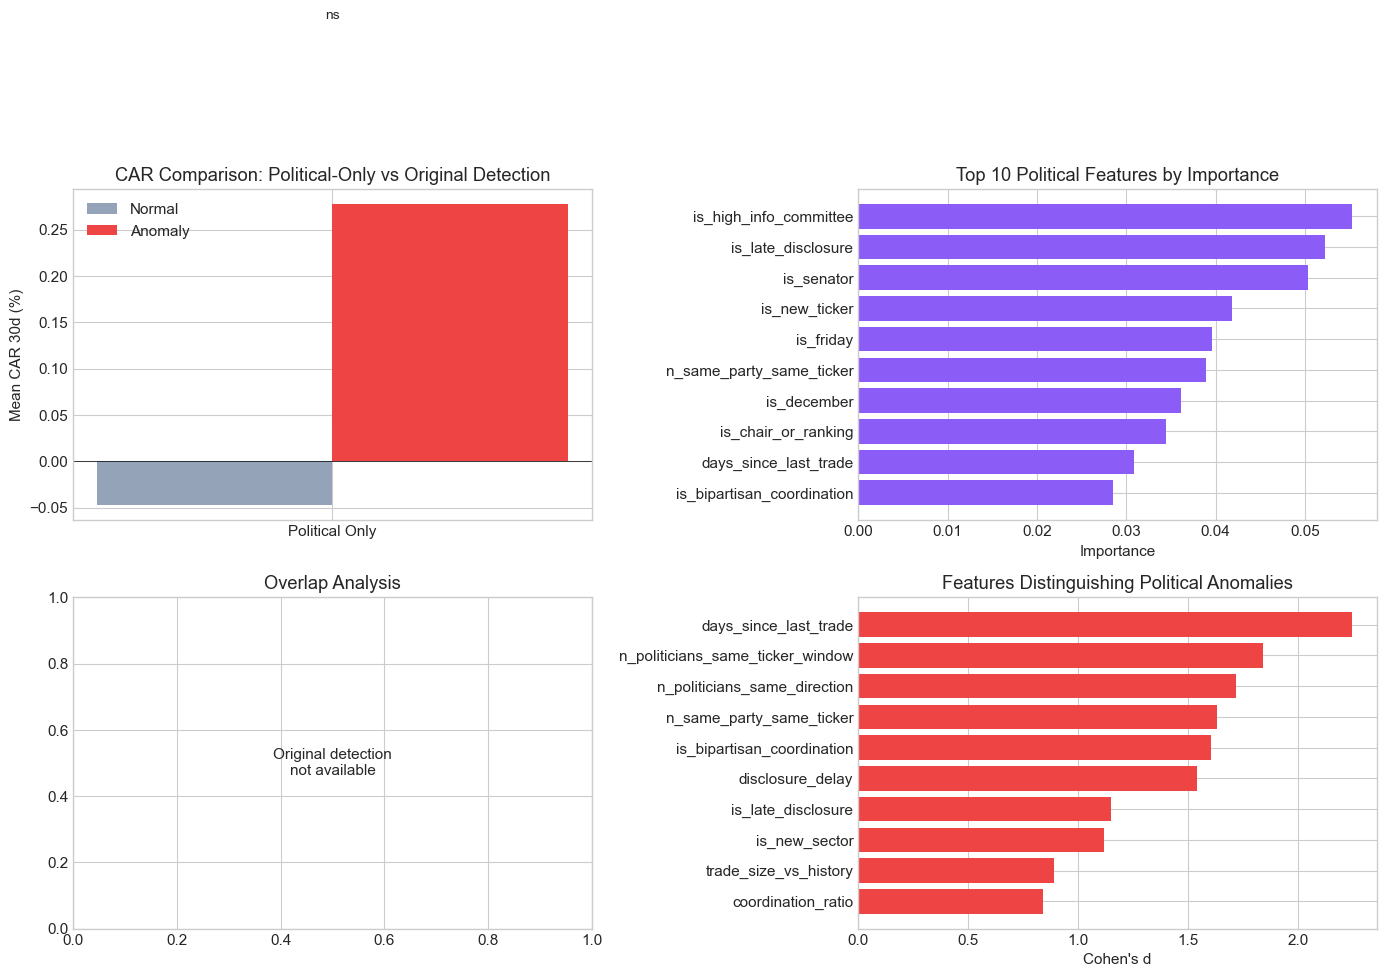

    Saved: fig_political_only_detection.png

[9] CAR by horizon for political anomalies...


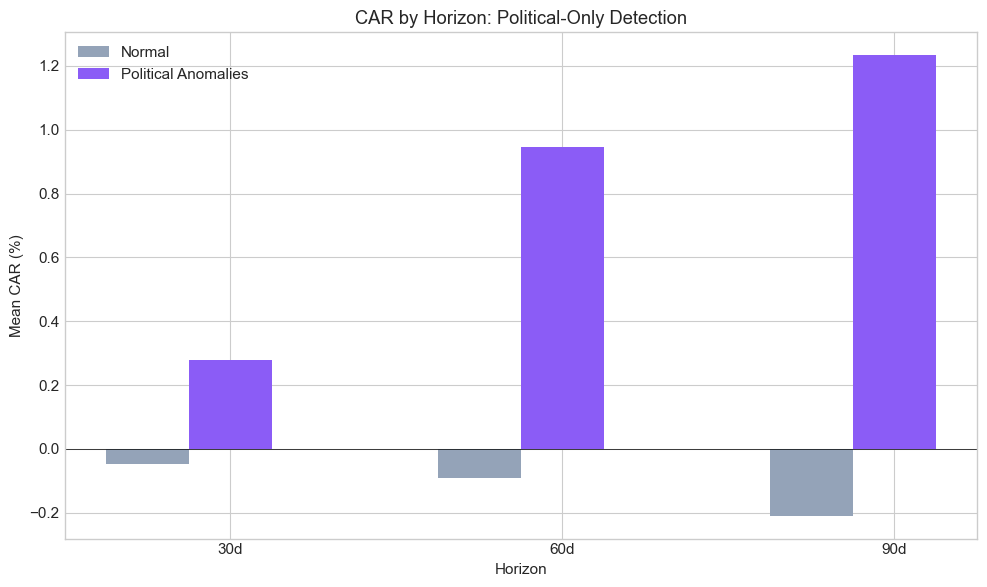

    Saved: fig_political_car_by_horizon.png

SUMMARY

Detection Method: Political Features Only (no market characteristics)
Features used: 24
Total trades: 79,903
Anomalies detected: 1,642 (2.1%)

CAR 30d Results (Political-Only Detection):
   Normal mean:     -0.05%
   Anomaly mean:    0.28%
   Difference:      0.32pp
   p-value:         0.2600

   ✗ NOT SIGNIFICANT: No evidence of information advantage
   → Political features alone don't identify informed trades

All results saved to: C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection\Robustness_Political

Exported anomaly flags to: C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection\Robustness_Political/political_anomaly_flags.csv


In [4]:
"""
================================================================================
ROBUSTNESS CHECK: ANOMALY DETECTION WITH POLITICAL FEATURES ONLY
================================================================================

Este script re-corre la detección de anomalías usando SOLO features políticos
(sin momentum, volatilidad, beta, etc.) para verificar si el outperformance
de las anomalías es genuino o un artefacto de seleccionar acciones volátiles.

Si las anomalías detectadas con features políticos tienen mayor CAR,
esto sería evidencia más fuerte de información privilegiada.

================================================================================
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_rel
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import os

# ============================================================================
# CONFIGURATION
# ============================================================================

INPUT_PATH = r'C:\Users\sebib\Documents\GitHub\US_Congress\data\congress_trades\congress_trades_anomaly_features.parquet'
OUTPUT_DIR = r'C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection\Robustness_Political'

os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'normal': '#94A3B8',
    'anomaly': '#EF4444',
    'political': '#8B5CF6',  # Purple for political-only
    'original': '#F59E0B'    # Orange for original
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
CONTAMINATION = 0.05

print("="*70)
print("ANOMALY DETECTION WITH POLITICAL FEATURES ONLY")
print("="*70)

# ============================================================================
# LOAD DATA
# ============================================================================

print("\n[1] Loading data...")
df = pd.read_parquet(INPUT_PATH)
print(f"    Loaded: {len(df):,} trades")

# ============================================================================
# DEFINE FEATURE SETS
# ============================================================================

print("\n[2] Defining feature sets...")

# FEATURES POLÍTICOS PUROS (no correlacionados mecánicamente con retornos)
FEATURES_POLITICAL = [
    # Timing y disclosure
    'disclosure_delay',
    'is_late_disclosure',
    
    # Características del político
    'is_senator',
    'is_chair_or_ranking',
    'is_high_info_committee',
    'committee_role_power',
    'n_committees',
    
    # Match comité-sector
    'committee_sector_match',
    
    # Coordinación entre políticos
    'n_politicians_same_ticker_window',
    'n_politicians_same_direction',
    'n_same_committee_same_ticker',
    'n_same_party_same_ticker',
    'is_bipartisan_coordination',
    'coordination_ratio',
    'n_politicians_same_sector_week',
    
    # Comportamiento histórico del político
    'days_since_last_trade',
    'trade_size_vs_history',
    'is_new_ticker',
    'is_new_sector',
    'politician_trade_count',
    'politician_6m_trade_count',
    
    # Timing calendar
    'is_friday',
    'is_quarter_end',
    'is_december',
]

# FEATURES DE MERCADO (los que queremos excluir)
FEATURES_MARKET = [
    'momentum_5d',
    'momentum_20d', 
    'momentum_60d',
    'realized_vol_30d',
    'beta_252d',
    'amihud_illiq_20d',
    'volume_ratio_30d',
    'abnormal_volume_30d',
    'is_high_vol_period',
    'is_high_beta',
]

# Filtrar features disponibles
FEATURES_POLITICAL = [f for f in FEATURES_POLITICAL if f in df.columns]
FEATURES_MARKET = [f for f in FEATURES_MARKET if f in df.columns]

print(f"    Political features available: {len(FEATURES_POLITICAL)}")
for f in FEATURES_POLITICAL:
    print(f"       - {f}")

print(f"\n    Market features (EXCLUDED): {len(FEATURES_MARKET)}")
for f in FEATURES_MARKET:
    print(f"       - {f}")

# ============================================================================
# PREPARE DATA
# ============================================================================

print("\n[3] Preparing data...")

# Necesitamos CAR para validación
CAR_COLS = ['car_ff3_30d', 'car_ff3_60d', 'car_ff3_90d']
CAR_COLS = [c for c in CAR_COLS if c in df.columns]

required_cols = FEATURES_POLITICAL + CAR_COLS
df_model = df.dropna(subset=required_cols).copy()

# Limpiar infinitos y outliers extremos
for col in FEATURES_POLITICAL:
    df_model[col] = df_model[col].replace([np.inf, -np.inf], np.nan)
    q01, q99 = df_model[col].quantile([0.01, 0.99])
    df_model[col] = df_model[col].clip(q01, q99)

df_model = df_model.dropna(subset=FEATURES_POLITICAL)
print(f"    Final sample: {len(df_model):,} trades")

# ============================================================================
# ANOMALY DETECTION WITH POLITICAL FEATURES ONLY
# ============================================================================

print("\n[4] Running anomaly detection with POLITICAL features only...")

scaler = RobustScaler()
X_political = scaler.fit_transform(df_model[FEATURES_POLITICAL])

# 4.1 Isolation Forest
print("    Training Isolation Forest...")
clf_if = IsolationForest(
    contamination=CONTAMINATION, 
    n_estimators=200, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
df_model['anomaly_political_if'] = (clf_if.fit_predict(X_political) == -1).astype(int)
df_model['score_political_if'] = -clf_if.score_samples(X_political)
print(f"       Isolation Forest anomalies: {df_model['anomaly_political_if'].sum():,}")

# 4.2 One-Class SVM
print("    Training One-Class SVM...")
idx_sample = np.random.choice(len(X_political), min(20000, len(X_political)), replace=False)
clf_svm = OneClassSVM(nu=CONTAMINATION, kernel='rbf', gamma='auto')
clf_svm.fit(X_political[idx_sample])
df_model['anomaly_political_svm'] = (clf_svm.predict(X_political) == -1).astype(int)
df_model['score_political_svm'] = -clf_svm.decision_function(X_political)
print(f"       One-Class SVM anomalies: {df_model['anomaly_political_svm'].sum():,}")

# 4.3 Local Outlier Factor (global, no por político)
print("    Training LOF...")
lof = LocalOutlierFactor(n_neighbors=50, contamination=CONTAMINATION)
df_model['anomaly_political_lof'] = (lof.fit_predict(X_political) == -1).astype(int)
df_model['score_political_lof'] = -lof.negative_outlier_factor_
print(f"       LOF anomalies: {df_model['anomaly_political_lof'].sum():,}")

# 4.4 Ensemble (consensus >= 2)
anomaly_cols_political = ['anomaly_political_if', 'anomaly_political_svm', 'anomaly_political_lof']
df_model['anomaly_political_vote'] = df_model[anomaly_cols_political].sum(axis=1)
df_model['anomaly_political_consensus'] = (df_model['anomaly_political_vote'] >= 2).astype(int)

print(f"\n    ENSEMBLE (consensus >= 2): {df_model['anomaly_political_consensus'].sum():,} "
      f"({df_model['anomaly_political_consensus'].mean():.1%})")

# ============================================================================
# COMPARE WITH ORIGINAL DETECTION
# ============================================================================

print("\n[5] Comparing with original detection...")

# Si existe la columna de anomalías originales
if 'anomaly_consensus_2' in df_model.columns:
    original_col = 'anomaly_consensus_2'
elif 'anomaly_if' in df_model.columns:
    # Recrear ensemble original si no existe
    orig_cols = ['anomaly_if', 'anomaly_svm', 'anomaly_lof_contextual', 'anomaly_collective']
    orig_cols = [c for c in orig_cols if c in df_model.columns]
    if len(orig_cols) >= 2:
        df_model['anomaly_original_vote'] = df_model[orig_cols].sum(axis=1)
        df_model['anomaly_consensus_2'] = (df_model['anomaly_original_vote'] >= 2).astype(int)
        original_col = 'anomaly_consensus_2'
    else:
        original_col = None
else:
    original_col = None

if original_col:
    # Overlap analysis
    both = ((df_model['anomaly_political_consensus'] == 1) & (df_model[original_col] == 1)).sum()
    only_political = ((df_model['anomaly_political_consensus'] == 1) & (df_model[original_col] == 0)).sum()
    only_original = ((df_model['anomaly_political_consensus'] == 0) & (df_model[original_col] == 1)).sum()
    neither = ((df_model['anomaly_political_consensus'] == 0) & (df_model[original_col] == 0)).sum()
    
    print(f"\n    Overlap Analysis:")
    print(f"       Both methods flag:        {both:,}")
    print(f"       Only political flags:     {only_political:,}")
    print(f"       Only original flags:      {only_original:,}")
    print(f"       Neither flags:            {neither:,}")
    
    # Jaccard similarity
    jaccard = both / (both + only_political + only_original) if (both + only_political + only_original) > 0 else 0
    print(f"       Jaccard similarity:       {jaccard:.2%}")

# ============================================================================
# VALIDATE: CAR COMPARISON
# ============================================================================

print("\n" + "="*70)
print("VALIDATION: CAR COMPARISON")
print("="*70)

def compare_car(df, anomaly_col, label):
    """Compare CAR between anomalous and normal trades"""
    results = []
    
    for car_col in CAR_COLS:
        normal = df[df[anomaly_col] == 0][car_col].dropna()
        anomaly = df[df[anomaly_col] == 1][car_col].dropna()
        
        if len(normal) == 0 or len(anomaly) == 0:
            continue
            
        t_stat, p_val = ttest_ind(anomaly, normal)
        
        results.append({
            'Method': label,
            'CAR': car_col,
            'N_Normal': len(normal),
            'N_Anomaly': len(anomaly),
            'Mean_Normal': normal.mean(),
            'Mean_Anomaly': anomaly.mean(),
            'Difference': anomaly.mean() - normal.mean(),
            't_statistic': t_stat,
            'p_value': p_val
        })
    
    return results

# Compare political-only detection
results_political = compare_car(df_model, 'anomaly_political_consensus', 'Political Only')

# Compare original detection (if available)
results_original = []
if original_col:
    results_original = compare_car(df_model, original_col, 'Original (All Features)')

# Combine results
all_results = results_political + results_original
results_df = pd.DataFrame(all_results)

if len(results_df) > 0:
    results_df['Significance'] = results_df['p_value'].apply(
        lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else ''))
    )
    
    print("\nTable: CAR Comparison - Political-Only vs Original Detection")
    print("-"*100)
    print(f"{'Method':<25} {'CAR':<15} {'Normal':>10} {'Anomaly':>10} {'Diff (pp)':>10} {'t-stat':>8} {'p-value':>10}")
    print("-"*100)
    
    for _, row in results_df.iterrows():
        print(f"{row['Method']:<25} {row['CAR']:<15} {row['Mean_Normal']*100:>9.2f}% "
              f"{row['Mean_Anomaly']*100:>9.2f}% {row['Difference']*100:>9.2f}pp "
              f"{row['t_statistic']:>8.2f} {row['p_value']:>9.4f}{row['Significance']}")
    
    print("-"*100)
    
    results_df.to_csv(f'{OUTPUT_DIR}/political_only_car_comparison.csv', index=False)

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print("\n[6] Feature importance (Isolation Forest)...")

# Permutation importance
from sklearn.inspection import permutation_importance

# Usar score de anomalía como "target" proxy
importance_results = []

for i, feat in enumerate(FEATURES_POLITICAL):
    # Shuffle one feature and see how much scores change
    X_shuffled = X_political.copy()
    np.random.shuffle(X_shuffled[:, i])
    scores_shuffled = -clf_if.score_samples(X_shuffled)
    
    # Correlation between original and shuffled scores
    corr = np.corrcoef(df_model['score_political_if'], scores_shuffled)[0, 1]
    importance = 1 - corr  # Higher = more important
    
    importance_results.append({
        'Feature': feat,
        'Importance': importance
    })

importance_df = pd.DataFrame(importance_results).sort_values('Importance', ascending=False)
print("\n    Top 10 most important political features:")
for _, row in importance_df.head(10).iterrows():
    print(f"       {row['Feature']:<35} {row['Importance']:.4f}")

importance_df.to_csv(f'{OUTPUT_DIR}/political_feature_importance.csv', index=False)

# ============================================================================
# CHARACTERIZE POLITICAL ANOMALIES
# ============================================================================

print("\n[7] Characterizing political anomalies...")

anomalies = df_model[df_model['anomaly_political_consensus'] == 1]
normal = df_model[df_model['anomaly_political_consensus'] == 0]

print(f"\n    Political anomalies: {len(anomalies):,}")

# Key characteristics
char_results = []

for feat in FEATURES_POLITICAL:
    mean_anom = anomalies[feat].mean()
    mean_norm = normal[feat].mean()
    std_pool = df_model[feat].std()
    
    diff = mean_anom - mean_norm
    cohen_d = diff / std_pool if std_pool > 0 else 0
    
    char_results.append({
        'Feature': feat,
        'Mean_Anomaly': mean_anom,
        'Mean_Normal': mean_norm,
        'Difference': diff,
        'Cohen_d': cohen_d
    })

char_df = pd.DataFrame(char_results).sort_values('Cohen_d', key=abs, ascending=False)

print("\n    Features that distinguish political anomalies (by Cohen's d):")
print("-"*70)
for _, row in char_df.head(10).iterrows():
    direction = "↑" if row['Cohen_d'] > 0 else "↓"
    print(f"       {row['Feature']:<35} d={row['Cohen_d']:>6.3f} {direction}")

char_df.to_csv(f'{OUTPUT_DIR}/political_anomaly_characteristics.csv', index=False)

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n[8] Generating figures...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: CAR comparison
if len(results_df) > 0:
    ax = axes[0, 0]
    
    # Filter to 30d CAR for cleaner plot
    df_30d = results_df[results_df['CAR'].str.contains('30d')]
    
    if len(df_30d) > 0:
        x = np.arange(len(df_30d))
        width = 0.35
        
        ax.bar(x - width/2, df_30d['Mean_Normal']*100, width, label='Normal', color=COLORS['normal'])
        ax.bar(x + width/2, df_30d['Mean_Anomaly']*100, width, label='Anomaly', color=COLORS['anomaly'])
        
        ax.set_xticks(x)
        ax.set_xticklabels(df_30d['Method'])
        ax.set_ylabel('Mean CAR 30d (%)')
        ax.set_title('CAR Comparison: Political-Only vs Original Detection')
        ax.legend()
        ax.axhline(0, color='black', linewidth=0.5)
        
        # Add significance stars
        for i, (_, row) in enumerate(df_30d.iterrows()):
            sig = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else 'ns'))
            y_pos = max(row['Mean_Normal'], row['Mean_Anomaly']) * 100 + 0.2
            ax.text(i, y_pos, sig, ha='center', fontsize=10)

# Panel 2: Feature importance
ax = axes[0, 1]
top_features = importance_df.head(10)
y_pos = np.arange(len(top_features))
ax.barh(y_pos, top_features['Importance'], color=COLORS['political'])
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 10 Political Features by Importance')

# Panel 3: Overlap with original (if available)
ax = axes[1, 0]
if original_col:
    labels = ['Both', 'Only Political', 'Only Original', 'Neither']
    sizes = [both, only_political, only_original, neither]
    colors_pie = [COLORS['anomaly'], COLORS['political'], COLORS['original'], COLORS['normal']]
    
    # Filter out zeros for cleaner pie
    non_zero = [(l, s, c) for l, s, c in zip(labels, sizes, colors_pie) if s > 0]
    if non_zero:
        labels, sizes, colors_pie = zip(*non_zero)
        ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
        ax.set_title('Overlap: Political-Only vs Original Detection')
else:
    ax.text(0.5, 0.5, 'Original detection\nnot available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Overlap Analysis')

# Panel 4: Cohen's d for distinguishing features
ax = axes[1, 1]
top_char = char_df.head(10)
colors_bar = [COLORS['anomaly'] if d > 0 else COLORS['normal'] for d in top_char['Cohen_d']]
y_pos = np.arange(len(top_char))
ax.barh(y_pos, top_char['Cohen_d'], color=colors_bar)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_char['Feature'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel("Cohen's d")
ax.set_title('Features Distinguishing Political Anomalies')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_political_only_detection.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("    Saved: fig_political_only_detection.png")

# ============================================================================
# ADDITIONAL: CAR BY HORIZON
# ============================================================================

print("\n[9] CAR by horizon for political anomalies...")

fig, ax = plt.subplots(figsize=(10, 6))

horizons = ['30d', '60d', '90d']
x = np.arange(len(horizons))
width = 0.25

# Political anomalies
car_political_anom = [anomalies[f'car_ff3_{h}'].mean()*100 for h in horizons if f'car_ff3_{h}' in anomalies.columns]
car_political_norm = [normal[f'car_ff3_{h}'].mean()*100 for h in horizons if f'car_ff3_{h}' in normal.columns]

ax.bar(x - width, car_political_norm, width, label='Normal', color=COLORS['normal'])
ax.bar(x, car_political_anom, width, label='Political Anomalies', color=COLORS['political'])

# Original anomalies (if available)
if original_col:
    orig_anom = df_model[df_model[original_col] == 1]
    car_original_anom = [orig_anom[f'car_ff3_{h}'].mean()*100 for h in horizons if f'car_ff3_{h}' in orig_anom.columns]
    ax.bar(x + width, car_original_anom, width, label='Original Anomalies', color=COLORS['original'])

ax.set_xticks(x)
ax.set_xticklabels(horizons)
ax.set_xlabel('Horizon')
ax.set_ylabel('Mean CAR (%)')
ax.set_title('CAR by Horizon: Political-Only Detection')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_political_car_by_horizon.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("    Saved: fig_political_car_by_horizon.png")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print(f"""
Detection Method: Political Features Only (no market characteristics)
Features used: {len(FEATURES_POLITICAL)}
Total trades: {len(df_model):,}
Anomalies detected: {df_model['anomaly_political_consensus'].sum():,} ({df_model['anomaly_political_consensus'].mean():.1%})
""")

if len(results_df) > 0:
    political_30d = results_df[(results_df['Method'] == 'Political Only') & (results_df['CAR'].str.contains('30d'))]
    if len(political_30d) > 0:
        row = political_30d.iloc[0]
        print(f"CAR 30d Results (Political-Only Detection):")
        print(f"   Normal mean:     {row['Mean_Normal']*100:.2f}%")
        print(f"   Anomaly mean:    {row['Mean_Anomaly']*100:.2f}%")
        print(f"   Difference:      {row['Difference']*100:.2f}pp")
        print(f"   p-value:         {row['p_value']:.4f}")
        
        if row['p_value'] < 0.05:
            print("\n   ✓ SIGNIFICANT: Political anomalies have higher CAR")
            print("   → This suggests genuine information advantage, not just volatility selection")
        else:
            print("\n   ✗ NOT SIGNIFICANT: No evidence of information advantage")
            print("   → Political features alone don't identify informed trades")

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("="*70)

# ============================================================================
# EXPORT ANOMALY FLAGS
# ============================================================================

# Save dataset with new anomaly flags
export_cols = ['trade_id', 'BioGuideID', 'Name', 'Ticker', 'trade_date', 'Transaction',
               'anomaly_political_if', 'anomaly_political_svm', 'anomaly_political_lof',
               'anomaly_political_consensus', 'score_political_if']

if original_col:
    export_cols.append(original_col)

export_cols = [c for c in export_cols if c in df_model.columns]
df_model[export_cols].to_csv(f'{OUTPUT_DIR}/political_anomaly_flags.csv', index=False)
print(f"\nExported anomaly flags to: {OUTPUT_DIR}/political_anomaly_flags.csv")